the below was coded with the help of llm

In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('../..')))

In [16]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.core.data_transforms import Transform

import matplotlib.pyplot as plt
import numpy as np
import torch

In [5]:
K_FOLDS = 5
N_VISITS = 4

In [6]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [8]:
pdd = PatientDataDispatcher(
    "../../config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [9]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [10]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [11]:
dmo_data.shape

torch.Size([428, 4, 7, 24])

In [12]:
# remove missing labels
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [13]:
dmo_labels.shape

torch.Size([428, 4, 1])

In [ ]:
patient_fatigue = dmo_labels.flatten(start_dim=1, end_dim=2)

In [34]:
patient_fatigue.shape

torch.Size([428, 4])

In [27]:
sampled_patient_fatigue = dmo_labels.flatten(start_dim=1, end_dim=2)[1::10]

In [29]:
sampled_patient_fatigue.shape

torch.Size([43, 4])

/tmp/ipykernel_604681/1977314359.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


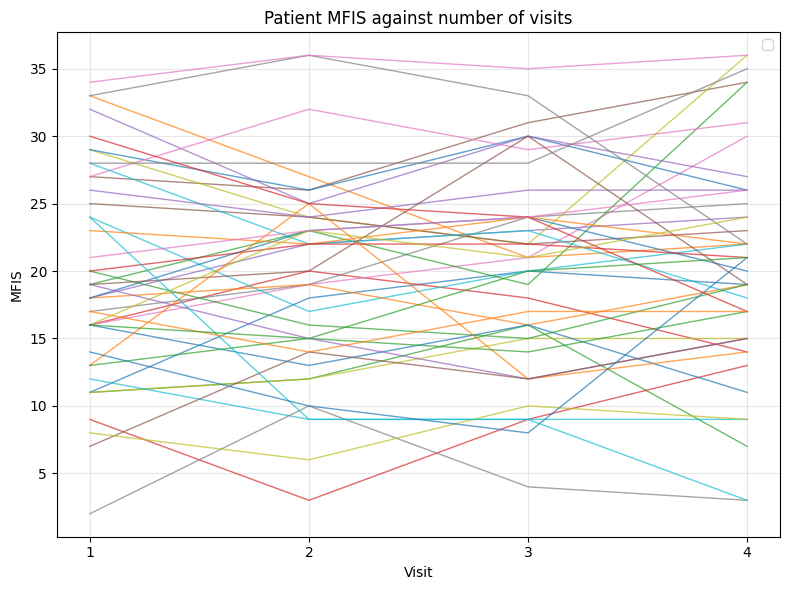

In [33]:
fatigue_np = sampled_patient_fatigue.detach().cpu().numpy()

visits = np.arange(1, fatigue_np.shape[1] + 1)

plt.figure(figsize=(8, 6))

# Plot each patient
for patient_idx in range(fatigue_np.shape[0]):
    plt.plot(
        visits,
        fatigue_np[patient_idx],
        alpha=0.7,
        linewidth=1
    )

# Plot mean trajectory
mean_fatigue = np.nanmean(fatigue_np, axis=0)

plt.xlabel("Visit")
plt.ylabel("MFIS")
plt.title("Patient MFIS against number of visits")
plt.xticks(visits)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

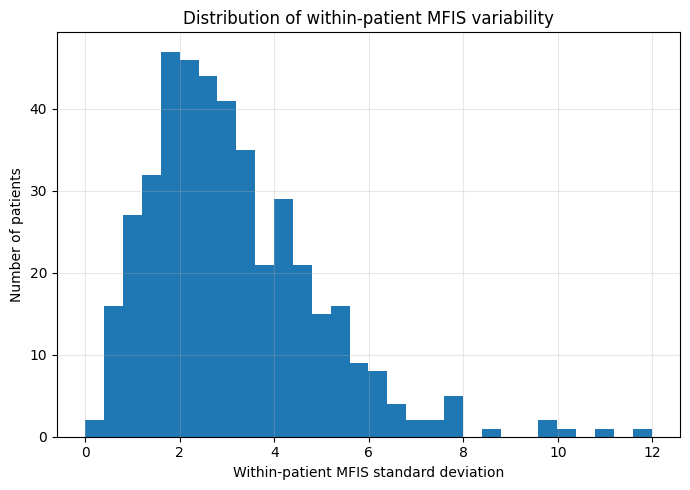

In [18]:
# Standard deviation across visits for each patient
patient_std = np.nanstd(fatigue_np, axis=1)

plt.figure(figsize=(7, 5))
plt.hist(patient_std, bins=30)

plt.xlabel("Within-patient MFIS standard deviation")
plt.ylabel("Number of patients")
plt.title("Distribution of within-patient MFIS variability")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

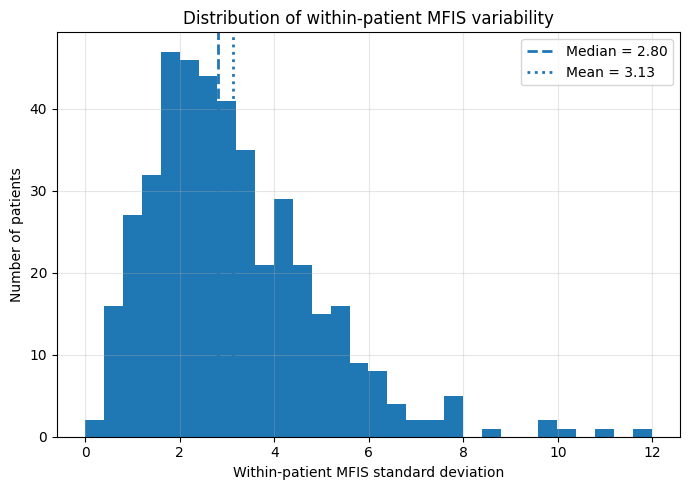

In [19]:
median_std = np.nanmedian(patient_std)
mean_std = np.nanmean(patient_std)

plt.figure(figsize=(7, 5))
plt.hist(patient_std, bins=30)

plt.axvline(median_std, linestyle="--", linewidth=2, label=f"Median = {median_std:.2f}")
plt.axvline(mean_std, linestyle=":", linewidth=2, label=f"Mean = {mean_std:.2f}")

plt.xlabel("Within-patient MFIS standard deviation")
plt.ylabel("Number of patients")
plt.title("Distribution of within-patient MFIS variability")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

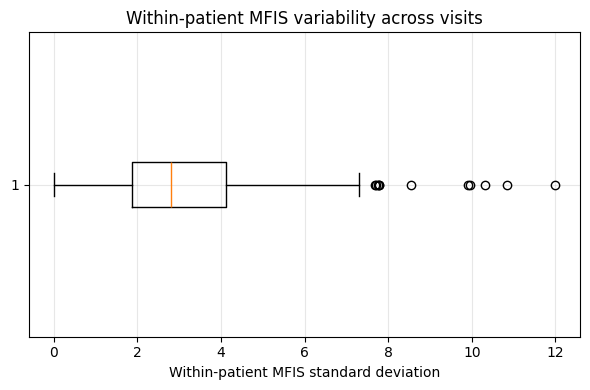

In [20]:
plt.figure(figsize=(6, 4))

plt.boxplot(patient_std, vert=False)

plt.xlabel("Within-patient MFIS standard deviation")
plt.title("Within-patient MFIS variability across visits")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
patient_std = torch.std(patient_fatigue.float(), dim=1, unbiased=False)
avg_patient_std = torch.mean(patient_std)
avg_patient_std

tensor(3.1294)